In [6]:
import numpy as np
np.testing.Tester = np.testing.TestCase
import pandas as pd
import json
import scipy
import os
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from feos.si import * # SI numbers and constants
# from si_units import * # SI numbers and constants

from feos.pcsaft import *
from feos.eos import *


from moth import *

msize=12
mwidth = 2
fsize=16
alpha=0.3
lsize = 2
framewidth = 3
markeredgewidth=3
markeredgewidth_no=10

In [ ]:
"""
choose specie, parameter-source and path
"""

saft_paras = "20191105_pure_parameters_feos.json"


name = "butane"
name = "hexane"
name = "heptane"
name = "octane"



#name = "nonane"
#name = "dodecane"

#name = "butanol"
#name = "propanol"


savepath = "results_thermal/"

In [8]:
"""
build path to save results
"""
try:
    os.mkdir(savepath)
except:
    None

try:
    os.mkdir(savepath+"/"+name)
except:
    None

lload


'octane'

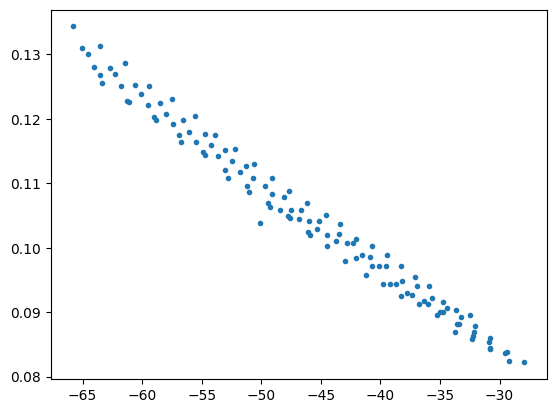

In [9]:
"""
load and process data

"""

parameters = PcSaftParameters.from_json(
    [name.split("_")[0]], 
    saft_paras, 
    #search_option="name"
)

M = parameters.pure_records[0].molarweight *(GRAM/MOL)
m = parameters.pure_records[0].model_record.m

ppath = "experimental/"+name+"/"+name+"_thermal_conductivity_proc.csv"

data = pd.read_csv(ppath)
print("lload")

#plt.plot( data["temperature"], np.log(data["pressure"]), "." )

data = data[ data["s_res"] < -10 ]


plt.plot( data["s_res"], data["thermal_conductivity"], "." )
name

In [10]:
poly_dict = {
    "propane": [3.51848530e+00,  8.98719202e-01, -6.57541675e-02,  4.85748207e-03,
       -3.89815685e-02,  3.23990347e-04,  2.68096625e-05],
    "butane": [2.93675606e+00,  6.58606541e-01, -3.54757854e-02,  3.43297168e-03,
       -2.34423967e-02, -3.20780717e-09,  2.77658981e-06],
    "hexane": [  3.201e+00 , 6.538e-01, -2.872e-02,  2.056e-03, -3.439e-02, -2.500e-09 , 9.602e-06],
    "heptane": [3.14259960e+00,  5.87862794e-01, -2.91491603e-02,  2.08778638e-03,
       -1.44664705e-02, -1.24873294e-19, -1.24873294e-19],
    "octane": [ 3.26730119e+00,  6.05701436e-01, -2.67738775e-02,  1.79895834e-03,
       -2.85554249e-02, -8.00307969e-19, -8.00307969e-19],
    "nonane": [ 3.25593263e+00,  5.94314410e-01, -3.34719291e-02,  2.06303415e-03,
       -1.34864713e-02, -7.79506607e-19, -7.79506607e-19],
    "dodecane": [ 3.14613724e+00,  4.33415774e-01, -1.43774533e-02,  8.43063298e-04,
        6.78612430e-03, -9.35159214e-05, -4.08358569e-06 ],
    "propanol":[3.1066556182709726, 0.3339730333762955, 0.009245313934974447, 0.0013849394768765822, -0.047430508899753754, -0.0005883123087159559, -3.303476589905937e-05],
    "butanol": [ 3.09736418e+00,  5.16332669e-01, -1.12147937e-02,  1.86113048e-03,
        -9.89413889e-02,  1.41800551e-07,  2.59356047e-06],
     "carbondioxide": [ 2.43423933e+00,  1.00134140e-01,  9.41409197e-02, -5.46421374e-03,
        8.63269060e-02, -1.07508664e-02,  4.90355962e-04],
     "water": [ 4.02290363e+00,  3.74513465e-01, -1.00705969e-01,  2.27679907e-03,
        1.80066136e-01,  7.67372189e-03,  5.27146621e-05],
    "water_new2": [4.03210064e+00,  3.71941896e-01, -1.03863165e-01,  2.68905680e-03,
        1.76920251e-01,  8.88540130e-03,  9.45182114e-07],      
    "water_hbond": [4.14071517e+00,  3.08348513e-01, -6.26207933e-02,  5.13599738e-03,
        1.60000000e-01,  8.43927589e-06,  1.00000000e-04],
    "water_hbond_fix":[ 4.17987307e+00,  2.73614916e-01, -9.99996458e-02,  1.30869622e-02, 0, 0, 0 ],
}

p = poly_dict[name]
p

[3.26730119,
 0.605701436,
 -0.0267738775,
 0.00179895834,
 -0.0285554249,
 -8.00307969e-19,
 -8.00307969e-19]

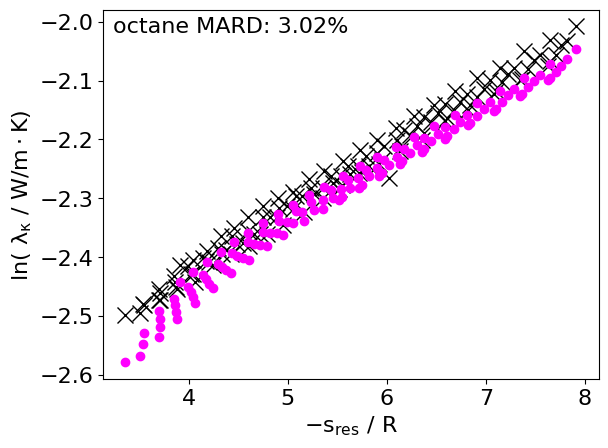

np.float64(3.0157308797514126)

In [16]:
x = -data["s_res"]/8.314
xx = p[1]*x + p[2]*x*x + p[3]*x*x*x
#xx = 2/3 * xx
#xx = 3/2 * xx


gamma = data["c_p"]/data["c_v"]


correction = m + 1




vf = np.log(data["V"] ) -  xx

kb = 1.380649e-23
R = 8.314
nav = 6.02214076e+23 



ln_thermal_conductivity = np.log( 2* correction * kb* ( nav / data["V"] )**(2/3) * np.sqrt( R*data["temperature"] / data["M"] ) ) + 1/4  * xx 
#ln_thermal_conductivity = np.log( 2* correction * kb* ( nav / data["V"] )**(2/3) * np.sqrt( R*data["temperature"] / data["M"] ) ) + 1/3  * xx 

fig, ax = plt.subplots()


plt.plot( -data["s_res"]/8.314, np.log( data["thermal_conductivity"] ),"kx",markersize=msize )
plt.plot( -data["s_res"]/8.314,  ln_thermal_conductivity,".",color="magenta",markersize=msize )


plt.xlabel(r"$-s_\text{res}~/~R$",fontsize=fsize)
plt.ylabel(r"$\ln(~\lambda_\kappa~/~W/m \cdot K)$",fontsize=fsize)

error = np.mean(np.abs( ( np.exp(ln_thermal_conductivity) - data["thermal_conductivity"]  ) / data["thermal_conductivity"] ))*100

plt.text(0.02, 0.98, name.split("_")[0]+' MARD: '+str(round(error,2))+"%",
     fontsize=fsize,
     horizontalalignment='left',
     verticalalignment='top',
     transform = ax.transAxes)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  


plt.savefig(savepath+"/"+name+"/"+name+"_thermal_conductivity.png",bbox_inches='tight')
plt.savefig(savepath+"/"+name+"/"+name+"_thermal_conductivity.pdf",bbox_inches='tight')

plt.show()
plt.close()  


error
